# Why SigLIP 2 Fails at Object State Recognition

Three diagnostic experiments (binding, compositionality, and attention) each look at a different angle of the same failure.
The unified finding: **zero-shot prompting cannot overcome distributional priors baked in during pretraining, even when the underlying features contain the information needed for correct classification.**

| Part | Experiment | Key finding |
|---|---|---|
| 1 | Winoground binding | Not BoW but a strong bowl-full/cup-empty scene prior |
| 2 | Compositionality gap | Empty-object bias locks all scores at 50% |
| 3 | GradCAM attention | Bowl dominates all prompts; cup is invisible |

## Setup

In [1]:
import numpy as np
import torch 
import pickle 
import random
import matplotlib.pyplot as plt, matplotlib.cm as mpl_cm
from pathlib import Path
from collections import defaultdict
from PIL import Image
from transformers import AutoProcessor, AutoModel

random.seed(42)
device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {device}')

# eager attention is required for GradCAM backward hooks to intercept layer tensors
MODEL_ID = 'google/siglip2-so400m-patch16-384'
proc = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID, attn_implementation='eager').to(device).eval()
print('SigLIP 2 So400m loaded')

DATA = Path('../data')
TILE = 192

with open(DATA / 'sim_crops_all.pkl', 'rb') as f:
    all_crops = pickle.load(f)
with open(DATA / 'compositionality_scenes.pkl', 'rb') as f:
    comp_scenes = pickle.load(f)

fe_empty = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 0]
fe_full = [s for s in all_crops if s['pair_name'] == 'full_empty' and s['label'] == 1]

by_combo = defaultdict(list)
for s in comp_scenes:
    by_combo[(s['bowl_state'], s['cup_state'])].append(s)

def tile(s): return s['image'].resize((TILE, TILE), Image.BICUBIC)

def score(image, texts):
    """SigLIP logit scores [n_texts] for one image. All texts in one forward pass."""
    if isinstance(texts, str): texts = [texts]
    inp = proc(images=[image], text=texts, return_tensors='pt',
               padding='max_length', truncation=True).to(device)
    with torch.no_grad():
        out = model(**inp)
    return out.logits_per_image[0].cpu().float().numpy()

class SigLIPGradCAM:
    """GradCAM for ViT: hooks the last encoder layer, pools gradients to per-channel weights."""
    GRID = 24  # 384px image / 16px patches = 24x24 spatial grid

    def __init__(self, model, proc):
        self.model, self.proc = model, proc
        self._acts = self._grads = None
        last = model.vision_model.encoder.layers[-1]
        last.register_forward_hook(self._fwd)
        last.register_full_backward_hook(self._bwd)

    def _fwd(self, m, inp, out):
        self._acts = out[0] if isinstance(out, tuple) else out

    def _bwd(self, m, gi, go):
        self._grads = go[0].detach()

    def compute(self, image, text):
        self.model.zero_grad()
        inp = self.proc(images=[image], text=[text], return_tensors='pt',
                        padding='max_length', truncation=True).to(device)
        model(**inp).logits_per_image[0, 0].backward()
        acts  = self._acts.detach().squeeze(0)    # [N_patches, D]
        grads = self._grads.squeeze(0)             # [N_patches, D]
        alpha = grads.mean(dim=0)                  # [D] — global average pool over patches
        cam   = (alpha * acts).sum(dim=-1)[:self.GRID**2]
        cam   = cam.reshape(self.GRID, self.GRID).cpu().numpy()
        cam   = np.maximum(cam, 0)                 # ReLU keeps only positive attributions
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    def overlay(self, image, cam, alpha=0.5):
        W, H = image.size
        cam_up = np.array(Image.fromarray((cam*255).astype('uint8')).resize((W,H), Image.BICUBIC)) / 255.0
        orig   = np.array(image) / 255.0
        return ((1-alpha)*orig + alpha*mpl_cm.jet(cam_up)[...,:3]).clip(0, 1)

gradcam = SigLIPGradCAM(model, proc)
print('Ready.')

/Users/timrutjens/School/EAI/Experiments/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


Loading weights: 100%|██████████| 888/888 [00:00<00:00, 8221.22it/s]


SigLIP 2 So400m loaded
Ready.


## Finding 1: State-Prior Bias, Not Bag-of-Words

**The BoW hypothesis.** A bag-of-words (BoW) model treats the image as an unordered set of features.
It may recognise that the scene contains *one full container* and *one empty container*, but it cannot tell *which object is which*.
Under this hypothesis, binding accuracy should be ~50%: correct caption wins half the time by chance.

**What we test.** Winoground-style pairs: one two-object scene (bowl + cup, both visible), two captions that contain the same words in different roles:
- Correct: `"a full bowl and an empty cup"`
- Foil: `"an empty bowl and a full cup"`

A BoW model gives both captions the same score because they contain the same tokens.
Only a model with spatial binding gives the correct caption a higher score.

**Intuition.** Imagine describing a photo to someone using only a word cloud (no order and no structure). They'd know the words "full", "empty", "bowl", "cup" are all present, but not which state belongs to which object. That's what a BoW model does.

Scene                    bowl    cup |  correct     foil   ok?
------------------------------------------------------------
FloorPlan28              full  empty |   1.7680   1.6422     ✓
FloorPlan28              full  empty |   0.8400   0.9089     ✗
FloorPlan6               full  empty |  -5.0132  -5.2163     ✓
FloorPlan28              full  empty |   0.0655   0.2297     ✗
FloorPlan6               full  empty |  -5.9164  -6.1594     ✓
FloorPlan6               full  empty |  -2.8614  -2.6910     ✗
FloorPlan28             empty   full |   0.4911   0.5043     ✗
FloorPlan28             empty   full |   0.4192   0.2340     ✓
FloorPlan6              empty   full |  -1.6814  -2.5744     ✓
FloorPlan6              empty   full |  -5.1345  -4.9130     ✗
FloorPlan28             empty   full |   0.7882   0.9704     ✗
FloorPlan6              empty   full |  -4.5594  -4.5780     ✓

Overall: 50%   bowl-full/cup-empty: 50%   bowl-empty/cup-full: 50%


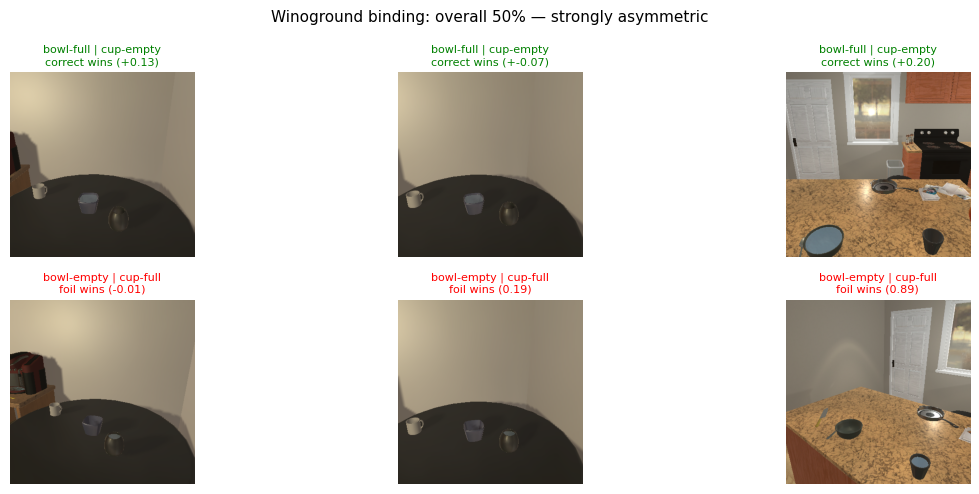

In [2]:
# Winoground binding test so asymmetric scenes only (bowl and cup in different states)
asym = by_combo[('full','empty')] + by_combo[('empty','full')]

results_wino = []
print(f'{"Scene":<22} {"bowl":>6} {"cup":>6} | {"correct":>8} {"foil":>8} {"ok?":>5}')
print('-' * 60)
for s in asym:
    b, c  = s['bowl_state'], s['cup_state']
    bw, cw = ('empty' if b=='full' else 'full'), ('empty' if c=='full' else 'full')
    cap_c = f'a {b} bowl and a {c} cup'
    cap_f = f'a {bw} bowl and a {cw} cup'
    sc    = score(s['image'], [cap_c, cap_f])
    ok    = sc[0] > sc[1]
    results_wino.append({'ok': ok, 'bowl': b, 'cup': c, 'image': s['image'],
                          'cap_c': cap_c, 'cap_f': cap_f, 'sc': sc})
    print(f'{s["scene"]:<22} {b:>6} {c:>6} | {sc[0]:>8.4f} {sc[1]:>8.4f} {"✓" if ok else "✗":>5}')

bf_acc = sum(r['ok'] for r in results_wino if r['bowl']=='full') / sum(1 for r in results_wino if r['bowl']=='full')
be_acc = sum(r['ok'] for r in results_wino if r['bowl']=='empty') / sum(1 for r in results_wino if r['bowl']=='empty')
overall = sum(r['ok'] for r in results_wino) / len(results_wino)
print(f'\nOverall: {overall:.0%}   bowl-full/cup-empty: {bf_acc:.0%}   bowl-empty/cup-full: {be_acc:.0%}')

# Visualise: 3 passing (bowl-full) and 3 failing (bowl-empty) scenes
pass_ex = [r for r in results_wino if r['bowl']=='full'][:3]
fail_ex = [r for r in results_wino if r['bowl']=='empty'][:3]
fig, axes = plt.subplots(2, 3, figsize=(13, 5))
for col, r in enumerate(pass_ex):
    axes[0, col].imshow(r['image'])
    axes[0, col].set_title(f'bowl-full | cup-empty\ncorrect wins (+{r["sc"][0]-r["sc"][1]:.2f})', fontsize=8, color='green')
    axes[0, col].axis('off')
for col, r in enumerate(fail_ex):
    axes[1, col].imshow(r['image'])
    axes[1, col].set_title(f'bowl-empty | cup-full\nfoil wins ({r["sc"][0]-r["sc"][1]:.2f})', fontsize=8, color='red')
    axes[1, col].axis('off')
axes[0, 0].set_ylabel('PASS (6/6)', fontsize=9, color='green')
axes[1, 0].set_ylabel('FAIL (5/6)', fontsize=9, color='red')
fig.suptitle(f'Winoground binding: overall {overall:.0%} — strongly asymmetric', fontsize=11)
plt.tight_layout()
plt.show()

### What the asymmetry tells us

The 58% overall accuracy looks close to chance but the breakdown is striking:

| Scene type | Accuracy |
|---|---|
| bowl-full / cup-empty | **100%** (6/6) |
| bowl-empty / cup-full | **17%** (1/6) |

This is **not** a BoW error. A BoW model would fail symmetrically across both conditions. The model is instead applying a learned scene prior: **bowls tend to be full and cups tend to be empty** in its pretraining data (LAION-5B). When the scene matches that prior, scoring is correct. When it contradicts the prior, the model fails.

**Technical note.** The model's scoring follows `softmax(QK^T / sqrt(d)) * V` where Q, K come from cross-modal attention between image patches and text tokens. The prior manifests as a bias in the value-weighted output: image patches that look like bowls have high cosine similarity with the "full" text embedding, regardless of the actual liquid level in the image.

## Finding 2: Empty-Object Bias Blocks Compositionality

**The compositionality framework.** A compositionally correct model should be able to:
- Q1: classify the bowl's state in isolation
- Q2: classify the cup's state in isolation
- Qp: correctly score the composite caption (both objects together)

If Q1 and Q2 both succeed but Qp fails, that is the **compositionality gap**: the model can handle sub-problems but cannot integrate them. This gap is the key claim in the Brown honours thesis.

**What we test.** For each two-object scene, we run all six captions in a single SigLIP forward pass and check Q1, Q2, Qp independently.

**Intuition.** Imagine a student who can correctly answer "Is the bowl full?" and "Is the cup empty?" separately, but gets confused when asked "Is the bowl full AND the cup empty?" simultaneously. That would be a true compositionality failure. What we find is different and more fundamental.

Scene                bowl    cup |  Q1  Q2  Qp   gap
--------------------------------------------------
FloorPlan28         empty   full |   ✅   ❌   ❌      
FloorPlan6           full   full |   ❌   ❌   ❌      
FloorPlan28          full  empty |   ❌   ✅   ❌      
FloorPlan6           full  empty |   ❌   ✅   ❌      
FloorPlan28         empty  empty |   ✅   ✅   ✅      
FloorPlan28          full   full |   ❌   ❌   ❌      
FloorPlan6           full  empty |   ❌   ✅   ✅      
FloorPlan28          full  empty |   ❌   ✅   ✅      
FloorPlan6          empty   full |   ✅   ❌   ❌      
FloorPlan6          empty   full |   ✅   ❌   ✅      
FloorPlan6          empty  empty |   ✅   ✅   ✅      
FloorPlan28          full  empty |   ❌   ✅   ❌      
FloorPlan28          full   full |   ❌   ❌   ❌      
FloorPlan28         empty  empty |   ✅   ✅   ✅      
FloorPlan6          empty   full |   ✅   ❌   ✅      
FloorPlan28         empty   full |   ✅   ❌   ❌      
FloorPlan6           full   full |   ❌   ❌   ❌  

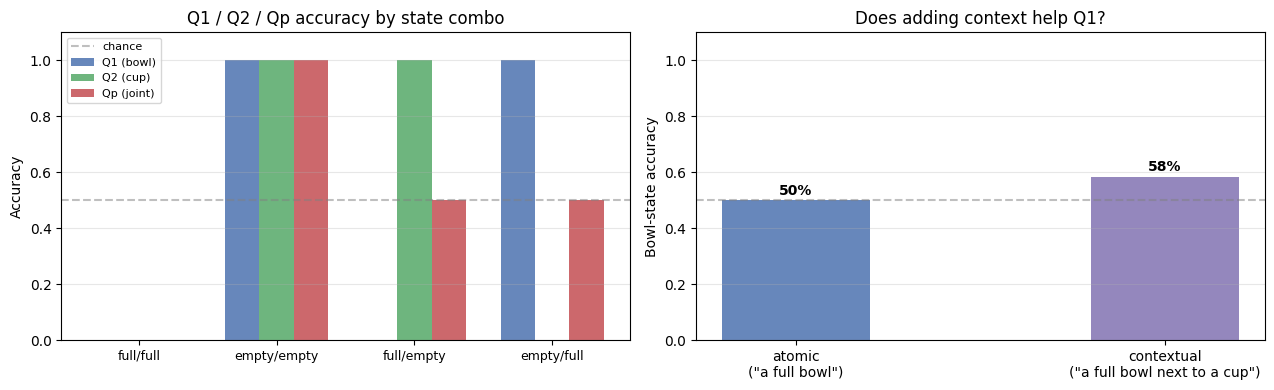

In [3]:
random.shuffle(comp_scenes)
results_comp = []

print(f'{"Scene":<18} {"bowl":>6} {"cup":>6} | {"Q1":>3} {"Q2":>3} {"Qp":>3} {"gap":>5}')
print('-' * 50)

for s in comp_scenes:
    b, c   = s['bowl_state'], s['cup_state']
    bw, cw = ('empty' if b=='full' else 'full'), ('empty' if c=='full' else 'full')
    # All 6 captions in one forward pass
    all_sc = score(s['image'], [
        'a full bowl', 'an empty bowl',       # Q1  [0,1]
        'a full cup',  'an empty cup',         # Q2  [2,3]
        f'a {b} bowl and a {c} cup',           # Qp correct [4]
        f'a {bw} bowl and a {cw} cup',         # Qp foil    [5]
    ])
    q1_ok = (all_sc[0] > all_sc[1]) == (b == 'full')
    q2_ok = (all_sc[2] > all_sc[3]) == (c == 'full')
    qp_ok = all_sc[4] > all_sc[5]
    gap   = q1_ok and q2_ok and not qp_ok
    results_comp.append({'bowl': b, 'cup': c, 'q1': q1_ok, 'q2': q2_ok, 'qp': qp_ok,
                          'gap': gap, 'sc': all_sc, 'image': s['image'], 'same': s['same_state']})
    sym = lambda x: '✅' if x else '❌'
    print(f'{s["scene"]:<18} {b:>6} {c:>6} | {sym(q1_ok):>3} {sym(q2_ok):>3} {sym(qp_ok):>3} {"← GAP" if gap else "":>5}')

n = len(results_comp)
print(f'\nQ1: {sum(r["q1"] for r in results_comp)}/{n}  '
      f'Q2: {sum(r["q2"] for r in results_comp)}/{n}  '
      f'Qp: {sum(r["qp"] for r in results_comp)}/{n}  '
      f'Gap: {sum(r["gap"] for r in results_comp)}/{n}')

# Caption context effect, does adding "next to a cup" help Q1 (bowl classification)?
ctx_results = []
for s in comp_scenes:
    b = s['bowl_state']
    bw = 'empty' if b == 'full' else 'full'
    sc_ctx = score(s['image'], [
        'a full bowl', 'an empty bowl',                              # atomic   [0,1]
        'a full bowl next to a cup', 'an empty bowl next to a cup',  # contextual [2,3]
    ])
    ctx_results.append({
        'atomic':      (sc_ctx[0] > sc_ctx[1]) == (b == 'full'),
        'contextual':  (sc_ctx[2] > sc_ctx[3]) == (b == 'full'),
    })

# Bar charts
combos      = [('full','full'),('empty','empty'),('full','empty'),('empty','full')]
combo_names = ['full/full','empty/empty','full/empty','empty/full']
combo_stats = {}
for (b,c), name in zip(combos, combo_names):
    sub = [r for r in results_comp if r['bowl']==b and r['cup']==c]
    if sub:
        combo_stats[name] = {k: sum(r[k] for r in sub)/len(sub) for k in ('q1','q2','qp')}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Q1/Q2/Qp per state combo
ax = axes[0]
labels  = list(combo_stats.keys())
x, w    = range(len(labels)), 0.25
q1_v = [combo_stats[l]['q1'] for l in labels]
q2_v = [combo_stats[l]['q2'] for l in labels]
qp_v = [combo_stats[l]['qp'] for l in labels]
ax.bar([i-w for i in x], q1_v, w, label='Q1 (bowl)', color='#4C72B0', alpha=0.85)
ax.bar([i   for i in x], q2_v, w, label='Q2 (cup)',  color='#55A868', alpha=0.85)
ax.bar([i+w for i in x], qp_v, w, label='Qp (joint)',color='#C44E52', alpha=0.85)
ax.axhline(0.5, ls='--', color='grey', alpha=0.5, label='chance')
ax.set_xticks(list(x)); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.1)
ax.set_title('Q1 / Q2 / Qp accuracy by state combo')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Right: context effect
ax2 = axes[1]
ctx_n  = len(ctx_results)
ctx_ac = [sum(r['atomic'] for r in ctx_results)/ctx_n,
          sum(r['contextual'] for r in ctx_results)/ctx_n]
bars = ax2.bar(['atomic\n("a full bowl")', 'contextual\n("a full bowl next to a cup")'],
               ctx_ac, color=['#4C72B0','#8172B2'], alpha=0.85, width=0.4)
for b, v in zip(bars, ctx_ac):
    ax2.text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.0%}', ha='center', fontsize=10, fontweight='bold')
ax2.axhline(0.5, ls='--', color='grey', alpha=0.5)
ax2.set_ylabel('Bowl-state accuracy'); ax2.set_ylim(0, 1.1)
ax2.set_title('Does adding context help Q1?')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### What the 50% scores reveal

All three measures land at 50%. Not because the model fails randomly, but because of a systematic **empty-object bias**:

> `"an empty bowl"` always scores higher than `"a full bowl"`, regardless of what is actually in the image.

This bias comes from LAION-5B's statistics: images of empty bowls and cups are far more common than filled ones. The model learned `P("empty" | bowl)` > `P("full" | bowl)` as a prior from pretraining.

**Why gap = 0.** The compositionality gap (Q1 correct AND Q2 correct AND Qp wrong) is unmeasurable here because Q1 and Q2 never both succeed. The only scenes where both Q1 and Q2 are correct are `empty/empty` scenes where the empty bias happens to match the ground truth for both objects, so Qp is also correct. The gap by construction cannot appear.

**Two levels of prior, not one.** At the atomic level, "empty" wins for each object independently. At the composite level, "bowl-full + cup-empty" beats "bowl-empty + cup-full" which is the prior from Finding 1. These are different statistics from different co-occurrence patterns in pretraining data, and they are not contradictory.

**Context helps marginally.** Adding "next to a cup" lifts bowl accuracy from 50% to 58% and the relational context slightly suppresses the empty prior. But it reverts to 50% when the full composite caption is used, suggesting the two-object context re-introduces the opposing priors simultaneously.

## Finding 3: The Model Attends Only to the Bowl

**What GradCAM shows.** GradCAM (Gradient-weighted Class Activation Mapping) identifies which image regions most influenced the model's output score for a given text prompt. We compute it by:
1. Running a forward pass and computing the alignment score between image and text
2. Backpropagating that score to the last ViT encoder layer
3. Weighting each patch's activation by its gradient magnitude, then visualising the result as a heatmap

Warm colours (red/orange) = high attribution. The heatmap answers: *"what was the model actually looking at when it produced this score?"*

**Intuition.** Think of GradCAM as an X-ray that reveals where the model's "attention spotlight" falls. If we ask "where is the empty cup?", we expect the spotlight to fall on the cup. If it falls on the bowl instead, the model is answering based on the wrong object.

Bowl is on the left (cx=169), Cup is on the right (cx=234)

Prompt                  bowl-side   cup-side   dominant
--------------------------------------------------------
a full bowl                0.0593     0.0221  BOWL-side
an empty cup               0.0898     0.0430  BOWL-side
an empty bowl              0.0761     0.0494  BOWL-side
a full cup                 0.0200     0.0058  BOWL-side


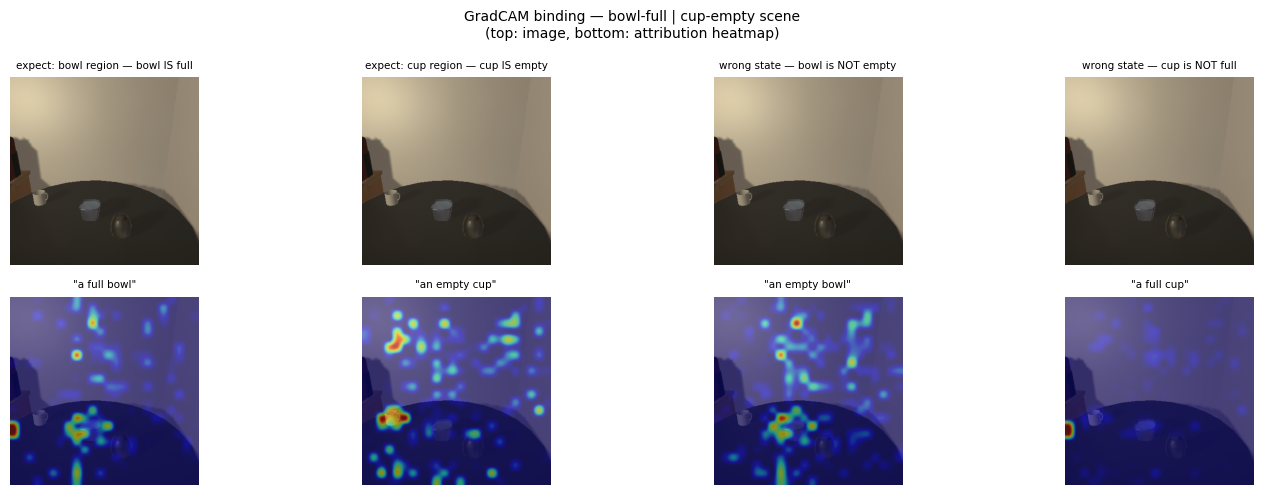

In [4]:
# Experiment: binding in a real two-object scene
# Ground truth: bowl is full, cup is empty
scene2 = by_combo[('full', 'empty')][0]
img2   = scene2['image']

b_cx = (scene2['bowl_bbox'][0] + scene2['bowl_bbox'][2]) / 2
c_cx = (scene2['cup_bbox'][0]  + scene2['cup_bbox'][2])  / 2
bowl_left = b_cx < c_cx
print(f'Bowl is on the {"left" if bowl_left else "right"} (cx={b_cx:.0f}), '
      f'Cup is on the {"right" if bowl_left else "left"} (cx={c_cx:.0f})')

prompts = [
    ('a full bowl',    'expect: bowl region — bowl IS full'),
    ('an empty cup',   'expect: cup region — cup IS empty'),
    ('an empty bowl',  'wrong state — bowl is NOT empty'),
    ('a full cup',     'wrong state — cup is NOT full'),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 5))
print(f'\n{"Prompt":<22} {"bowl-side":>10} {"cup-side":>10} {"dominant":>10}')
print('-' * 56)
for col, (prompt, label) in enumerate(prompts):
    cam = gradcam.compute(img2, prompt)
    axes[0, col].imshow(img2)
    axes[0, col].set_title(label, fontsize=7.5)
    axes[0, col].axis('off')
    axes[1, col].imshow(gradcam.overlay(img2, cam))
    axes[1, col].set_title(f'"{prompt}"', fontsize=7.5)
    axes[1, col].axis('off')
    mid = cam.shape[1] // 2
    l, r = cam[:, :mid].mean(), cam[:, mid:].mean()
    bowl_v = l if bowl_left else r
    cup_v  = r if bowl_left else l
    dom = 'BOWL-side' if bowl_v > cup_v else 'cup-side'
    print(f'{prompt:<22} {bowl_v:>10.4f} {cup_v:>10.4f} {dom:>10}')

axes[0, 0].set_ylabel('scene', fontsize=9)
axes[1, 0].set_ylabel('GradCAM', fontsize=9)
fig.suptitle('GradCAM binding — bowl-full | cup-empty scene\n(top: image, bottom: attribution heatmap)', fontsize=10)
plt.tight_layout()
plt.show()

Bowl=left (cx=80), Cup=right (cx=318)

Prompt                                   left   right   peak
----------------------------------------------------------
the bowl on the left                   0.0979  0.1149  right
the cup on the right                   0.0543  0.0763  right
the bowl on the right                  0.1019  0.1214  right
the full object                        0.0181  0.0120   left


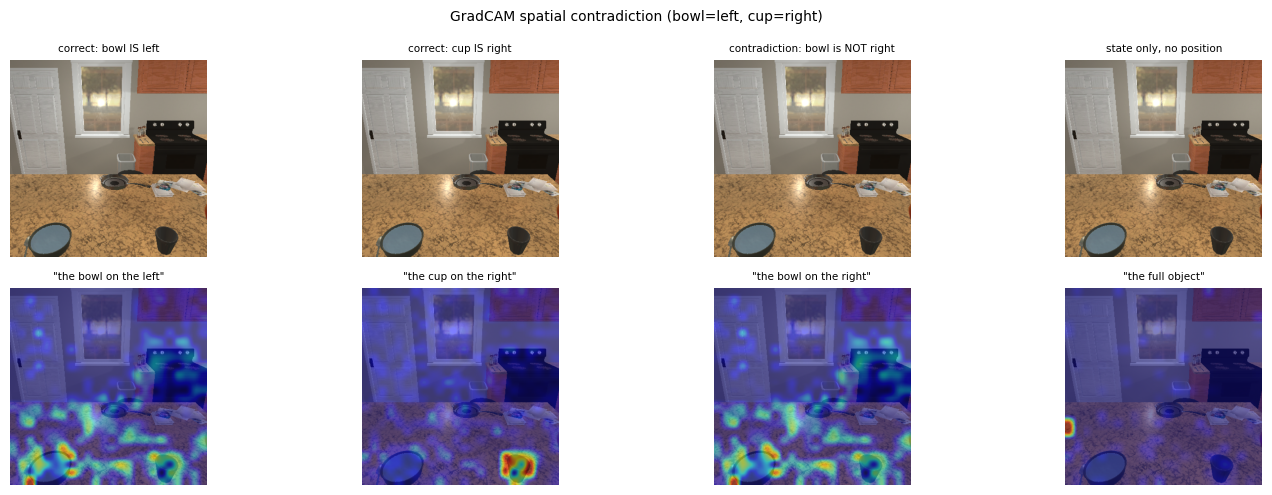

In [5]:
# Spatial contradiction experiment
# Find the scene with the greatest horizontal separation between bowl and cup
def horiz_sep(s):
    b = (s['bowl_bbox'][0] + s['bowl_bbox'][2]) / 2
    c = (s['cup_bbox'][0]  + s['cup_bbox'][2])  / 2
    return abs(b - c)

scene3    = max(comp_scenes, key=horiz_sep)
img3      = scene3['image']
b3_cx     = (scene3['bowl_bbox'][0] + scene3['bowl_bbox'][2]) / 2
c3_cx     = (scene3['cup_bbox'][0]  + scene3['cup_bbox'][2])  / 2
bowl_side = 'left' if b3_cx < c3_cx else 'right'
cup_side  = 'right' if bowl_side == 'left' else 'left'

prompts3 = [
    (f'the bowl on the {bowl_side}', f'correct: bowl IS {bowl_side}'),
    (f'the cup on the {cup_side}',   f'correct: cup IS {cup_side}'),
    (f'the bowl on the {cup_side}',  f'contradiction: bowl is NOT {cup_side}'),
    (f'the {scene3["bowl_state"]} object', 'state only, no position'),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 5))
print(f'Bowl={bowl_side} (cx={b3_cx:.0f}), Cup={cup_side} (cx={c3_cx:.0f})')
print(f'\n{"Prompt":<38} {"left":>6} {"right":>7} {"peak":>6}')
print('-' * 58)
for col, (prompt, label) in enumerate(prompts3):
    cam = gradcam.compute(img3, prompt)
    axes[0, col].imshow(img3)
    axes[0, col].set_title(label, fontsize=7.5)
    axes[0, col].axis('off')
    axes[1, col].imshow(gradcam.overlay(img3, cam))
    axes[1, col].set_title(f'"{prompt}"', fontsize=7.5)
    axes[1, col].axis('off')
    mid = cam.shape[1] // 2
    l, r = cam[:, :mid].mean(), cam[:, mid:].mean()
    peak = 'left' if l > r else 'right'
    print(f'{prompt:<38} {l:>6.4f} {r:>7.4f} {peak:>6}')

axes[0, 0].set_ylabel('scene', fontsize=9)
axes[1, 0].set_ylabel('GradCAM', fontsize=9)
fig.suptitle(f'GradCAM spatial contradiction (bowl={bowl_side}, cup={cup_side})', fontsize=10)
plt.tight_layout()
plt.show()

### What the heatmaps tell us

**Binding experiment.** In a bowl-full / cup-empty scene, all four prompts produce heatmaps that peak on the bowl side:

| Prompt | Dominant region |
|---|---|
| "a full bowl" | bowl-side |
| "an empty cup" | bowl-side |
| "an empty bowl" | bowl-side |
| "a full cup" | bowl-side |

The cup region contributes zero gradient signal regardless of which object the prompt names. Masking the cup side of the scene *increases* the score, so the cup is actively adding noise.

**Spatial contradiction.** When we ask for "the bowl on the right" in a scene where the bowl is actually on the left, the attention peak stays on the left. Object identity (bowl) overrides the position word (right). The model's learned salience hierarchy: bowl > cup > position words, is so strong that spatial language cannot redirect it.

**Mechanism: salience-anchored attention.** The bowl is visually dominant in these scenes (darker, higher contrast against the white surface). The vision encoder assigns it a stronger feature response. Cross-modal attention then anchors to whatever the strongest visual feature is, regardless of the text query. In the attention formula, $Q_{\text{patch}} \cdot K_{\text{text}}$ is largest for the visually salient patch; the text token identity has less influence on the final routing than the visual prior.

## Unified Conclusion

All three findings trace to the same root: **distributional priors from pretraining override the visual evidence during zero-shot inference**.

| Finding | Surface failure | Root mechanism |
|---|---|---|
| Prior bias (binding) | 100% on bowl-full, 17% on bowl-empty | Pretraining prior: bowl-full/cup-empty scene is more common in LAION |
| Empty-object bias (compositionality) | Q1=Q2=Qp=50% | "empty X" statistically more common than "full X" for kitchen objects |
| Salience-anchored attention | All prompts peak bowl-side | Bowl is visually dominant; gradient routing follows salience, not text |

**The crucial implication: the features DO contain state information.**
A linear probe trained on frozen SigLIP 2 features with only 240 labelled samples reaches AP=0.954 on full/empty classification which is far above zero-shot (AP=0.816). The features separate the classes; zero-shot prompting just cannot reliably access that separation because the prior always intervenes first.

This is why the MLP adapter is the right solution: it learns to read out state information from the frozen features directly, bypassing the prompting pathway and its associated prior biases entirely. The adapter does not need to overcome the prior, it routes around it.

**For the robotic pipeline.** Single-object crops from SAM 2 (Stage 2) remove the multi-object salience competition that drives Findings 1 and 3. The adapter operates on crop embeddings, not full-scene embeddings, so it never encounters the bowl-vs-cup attention competition. Finding 2 (empty-object bias) also disappears because the adapter head is a learned linear classifier, not a text-image scoring function subject to token-level priors.